In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv(r'C:\Users\Neha\Downloads\23rd, 24th, 26th, - Svr, Dtr, Rf, Knn\23rd, 24th, 26th, - Svr, Dtr, Rf, Knn\RESUME PROJECT -- PRICE PREDICTION\Avocado.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


In [4]:
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [5]:
df.isnull().sum()

Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64

In [6]:
df = df.drop(['Unnamed: 0','4046','4225','4770','Date'],axis=1)

In [7]:
df.head()

,AveragePrice,Total Volume,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,1.33,64236.62,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1.35,54876.98,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,0.93,118220.22,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,1.08,78992.15,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,1.28,51039.60,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


## 1. Which region are the lowest and highest prices of Avocado?
##    2. What is the highest region of avocado production?
##    3. What is the average avocado prices in each year?
##    4. What is the average avocado volume in each year?

In [15]:
def get_average(df,column):
    return sum(df[column])/len(df)

In [19]:
def get_average_between_two_columns(df,column1,column2):
    List = list(df[column1].unique())
    average=[]
    
    for i in List:
        x=df[df[column1]==i]
        column1_average=get_average(x,column2)
        average.append(column1_average)
        
    df_column1_column2=pd.DataFrame({'column1': List,'column2': average})
    column1_column2_sorted_index=df_column1_column2.column2.sort_values(ascending=False).index.values
    column1_column2_sorted_data=df_column1_column2.reindex(column1_column2_sorted_index)

    return column1_column2_sorted_data


In [13]:
def plot(data,xlabel,ylabel):
    plt.figure(figsize=(15,5))
    ax=sns.barplot(x=data.column1,y=data.column2,palette='rocket')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(('Average '+ylabel+ 'of Avocado according to '+xlabel))

## Which region are the highest and lowest prices of avocado?

C:\Users\Neha\AppData\Local\Temp\ipykernel_3284\4290966046.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x=data.column1,y=data.column2,palette='rocket')


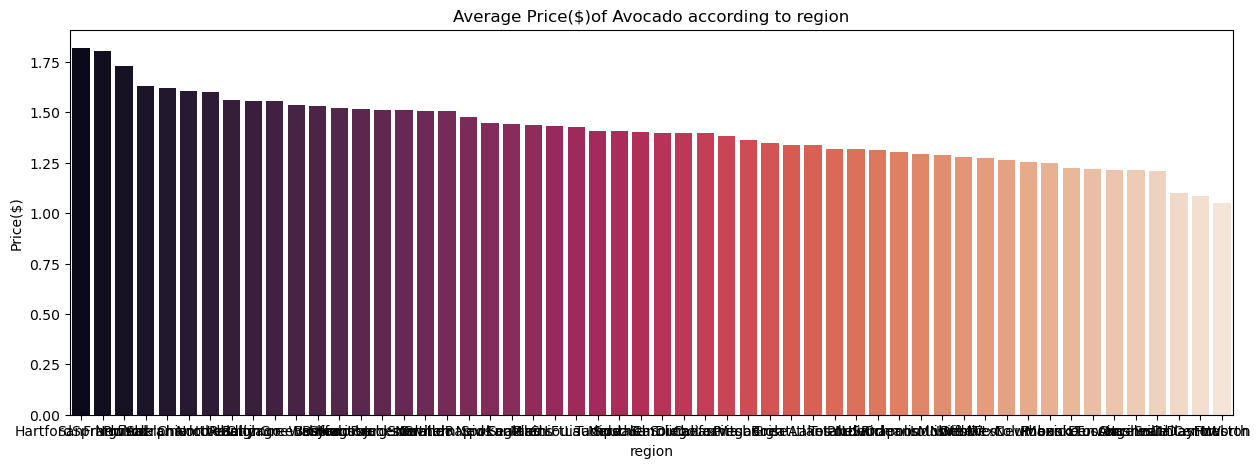

In [20]:
data1 = get_average_between_two_columns(df,'region', 'AveragePrice')
plot(data1,'region','Price($)')

In [21]:
print(data1['column1'].iloc[-1],'is the region providing Avocado with lowest price')

Houston is the region providing Avocado with lowest price


##  Which region is the highest Avocado production?

### Checking any outlier vaalue there or not !

Text(0.5, 1.0, 'Boxplot representing outlier')

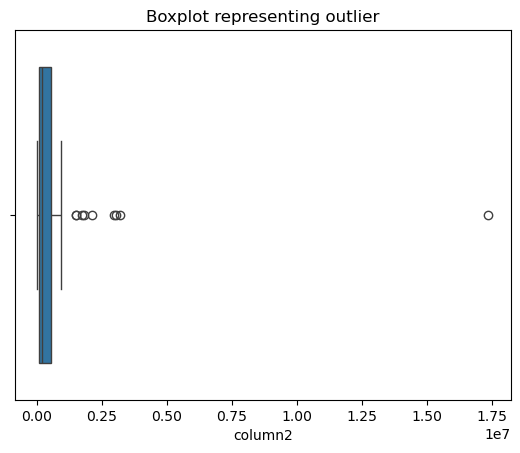

In [22]:
data2 = get_average_between_two_columns(df,'region','Total Volume')
sns.boxplot(x=data2.column2).set_title('Boxplot representing outlier')

In [24]:
outlier_region = data2[data2.column2>10000000]
print(outlier_region ['column1'].iloc[-1],'is the outlier value')

TotalUS is the outlier value


### Removing the outlier value.

In [25]:
outlier_region.index
data2 = data2.drop(outlier_region.index, axis=0)

C:\Users\Neha\AppData\Local\Temp\ipykernel_3284\4290966046.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x=data.column1,y=data.column2,palette='rocket')


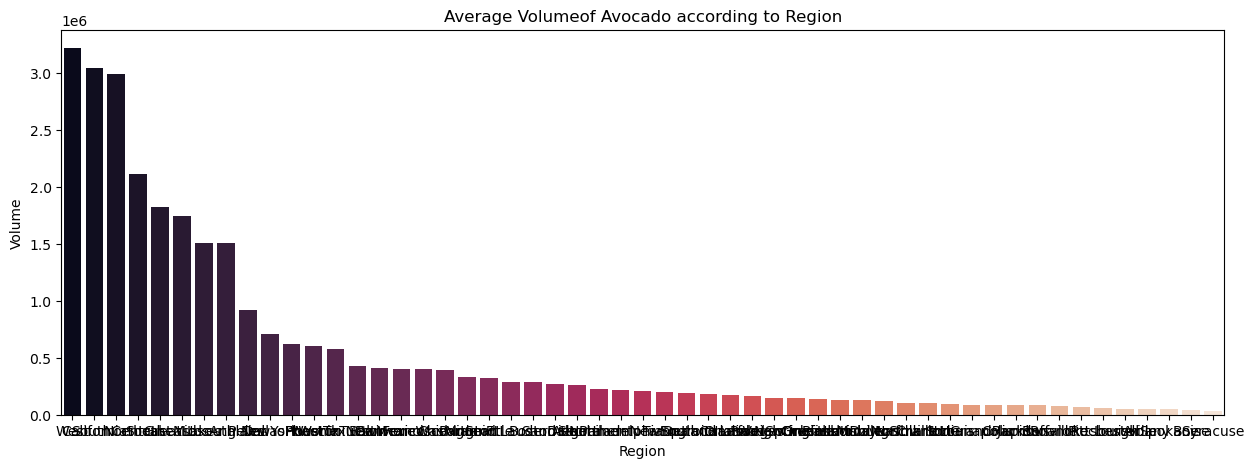

In [26]:
plot(data2,'Region','Volume')

## What is the average prices of Avocado in each year?

C:\Users\Neha\AppData\Local\Temp\ipykernel_3284\4290966046.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x=data.column1,y=data.column2,palette='rocket')


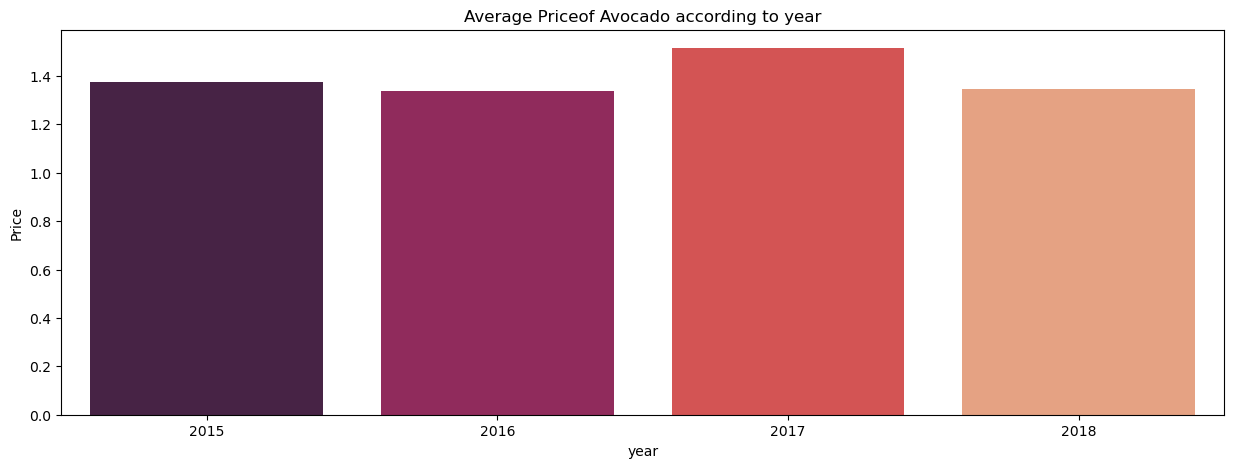

In [27]:
data3 = get_average_between_two_columns(df,'year','AveragePrice')
plot(data3,'year','Price')

## What is the average Avocado volume in each year?

C:\Users\Neha\AppData\Local\Temp\ipykernel_3284\4290966046.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x=data.column1,y=data.column2,palette='rocket')


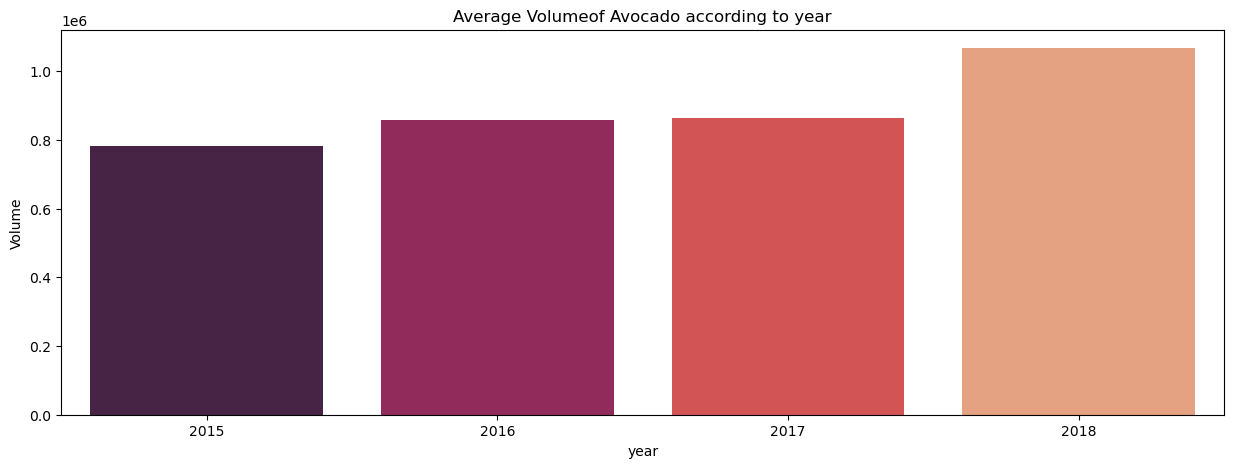

In [28]:
data4 = get_average_between_two_columns(df,'year','Total Volume')
plot(data4,'year','Volume')

# DATA MODELING

## changing some column types to categories

In [30]:
df['region'] = df['region'].astype('category')
df['region'] = df['region'].cat.codes

df['type'] = df['type'].astype('category')
df['type'] = df['type'].cat.codes

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AveragePrice  18249 non-null  float64
 1   Total Volume  18249 non-null  float64
 2   Total Bags    18249 non-null  float64
 3   Small Bags    18249 non-null  float64
 4   Large Bags    18249 non-null  float64
 5   XLarge Bags   18249 non-null  float64
 6   type          18249 non-null  int8   
 7   year          18249 non-null  int64  
 8   region        18249 non-null  int8   
dtypes: float64(6), int64(1), int8(2)
memory usage: 1.0 MB


In [32]:
df.head()

,AveragePrice,Total Volume,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,1.33,64236.62,8696.87,8603.62,93.25,0.0,0,2015,0
1,1.35,54876.98,9505.56,9408.07,97.49,0.0,0,2015,0
2,0.93,118220.22,8145.35,8042.21,103.14,0.0,0,2015,0
3,1.08,78992.15,5811.16,5677.40,133.76,0.0,0,2015,0
4,1.28,51039.60,6183.95,5986.26,197.69,0.0,0,2015,0


### splitting x and y data

In [33]:
x = df.drop(['AveragePrice'],axis=1)
y = df['AveragePrice']

### splitting data into training and testing dataset

In [34]:
x_train,x_test,y_train,y_test = train_test_split(x,
                                                 y,
                                                 test_size=0.3,
                                                 random_state=15)

In [35]:
print("Training Set:",x_train.shape, '-',y_train.shape[0],'samples')
print("Testing Set:",x_test.shape, '-' ,y_test.shape[0],'samples')

Training Set: (12774, 8) - 12774 samples
Testing Set: (5475, 8) - 5475 samples


In [37]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()